In [3]:
# Preamble
%load_ext autoreload
# %load_ext memory_profiler
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import maglab.formats.mumax3 as mx3
import maglab.analysis.ringdown as rd
import maglab.loaders.ringdown as l_rd
import maglab.loaders.utils as l_ut

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"
table = mx3.read_table(TABLE_PATH)
# table.loc[0, ["mx ()", "my ()", "mz ()"]].to_numpy()
# table.loc[:, table.columns.str.contains("mx|my|mz")]
# table.loc[0, table.columns.str.contains("B_extx|B_exty|B_extz")]
l_ut.compute_dot_vectors(table, ["m", "B_ext"], direction="B_ext")
# table

[array([-1.12721540e-10,  4.52447720e-07,  8.95513100e-07, ...,
        -1.61017460e-08, -1.38172185e-08, -1.07641210e-08], shape=(1201,)),
 array([ 8.3346096e-22,  7.8623110e-08, -2.2975273e-09, ...,
         1.8228659e-10,  4.0687160e-09,  2.3830931e-23], shape=(1201,))]

(0.0, 18.0)

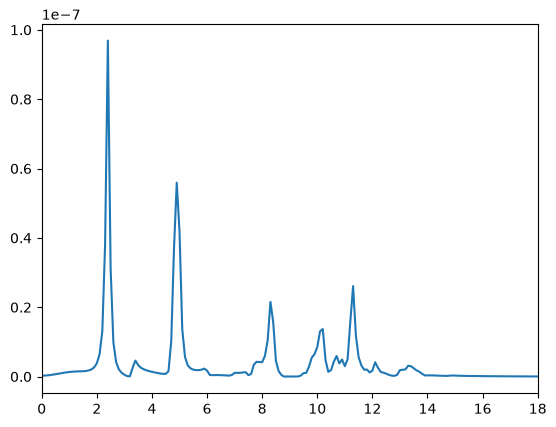

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"

df = l_rd.load_mag_avg_ringdown(TABLE_PATH)
plt.plot(df["frequency"], df["absorption"])
plt.xlim(0, 18)

In [40]:
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-05-22 AASI Dynamics 2x2\1-1\1-1_phi0_3\1-1_phi0_3exct_B000060.out")
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out")
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_maxerr8.out")
# (psd, phase), (frequencies, psd_spectrum) = l_rd.load_ringdown(DIRPATH)
# plt.plot(frequencies, psd_spectrum)

spec, freqs, bls, fmr = l_rd.load_ringdown(DIRPATH)

Loading OVF files: 100%|██████████| 1201/1201 [00:01<00:00, 754.00 files/s]


Text(0.5, 0, 'Frequency (GHz)')

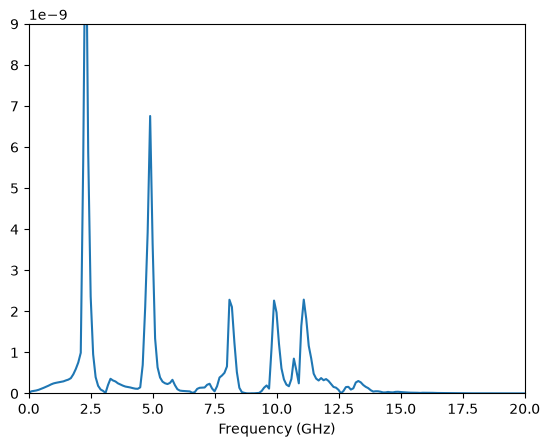

In [45]:
plt.plot(freqs / 1e9, fmr)
plt.xlim(0, 20)
# plt.ylim(0, 0.3e-6)
# plt.ylim(0, 0.2e-8)
# plt.ylim(0, 1.2e-6)
plt.ylim(0, 0.9e-8)
plt.xlabel("Frequency (GHz)")


2.398001665278934


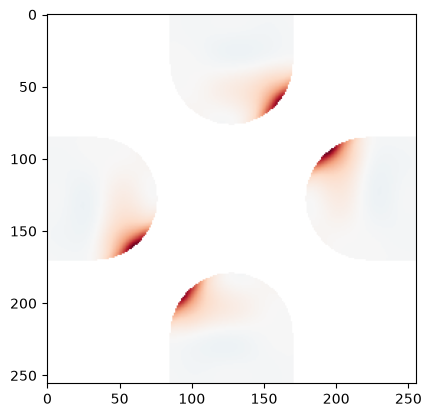

3.3971690258118232


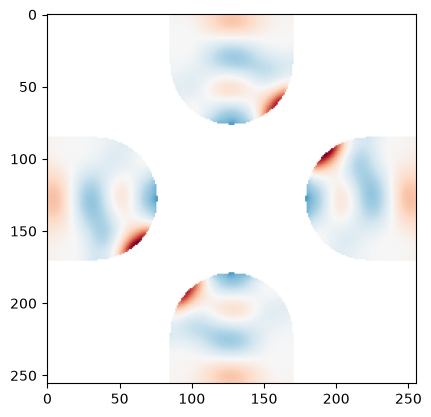

4.895920066611158


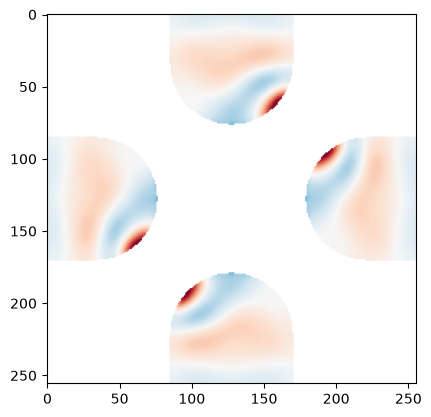

5.8950874271440465


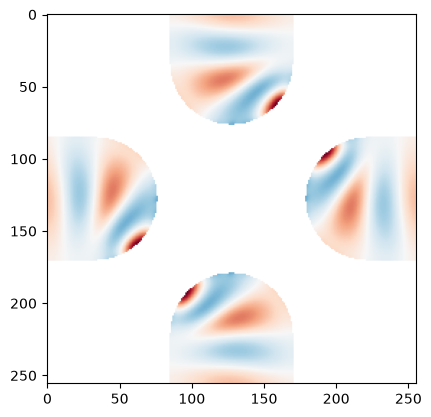

6.294754371357203


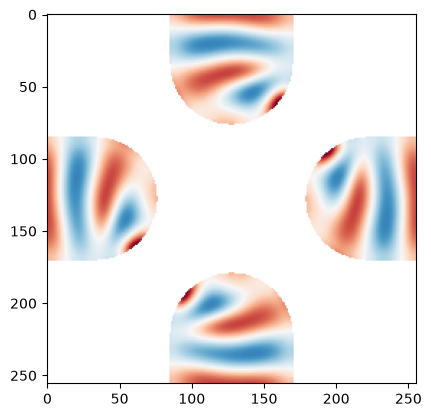

7.393838467943381


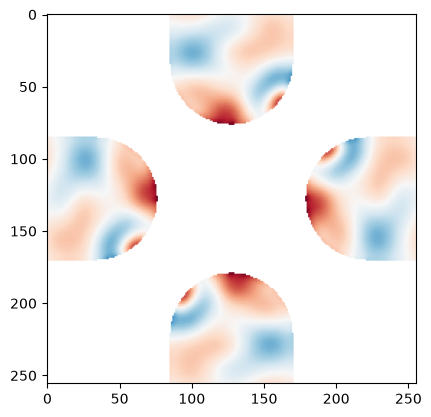

7.793505412156536


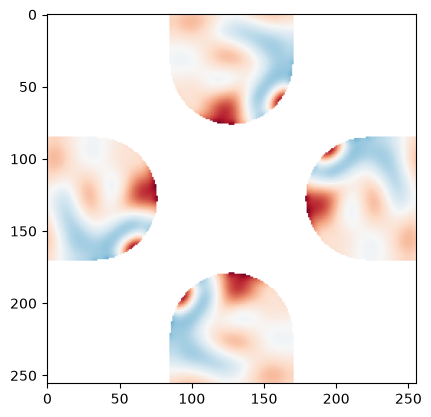

8.29308909242298


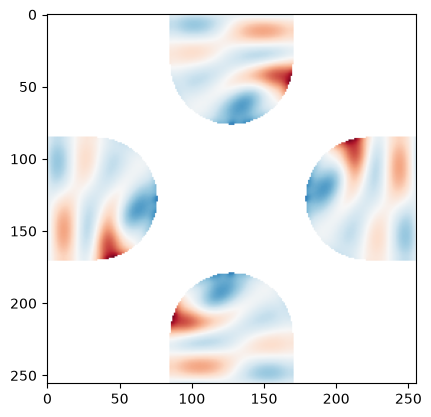

8.892589508742715


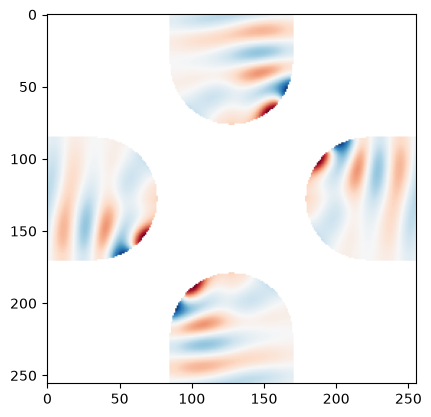

10.191507077435471


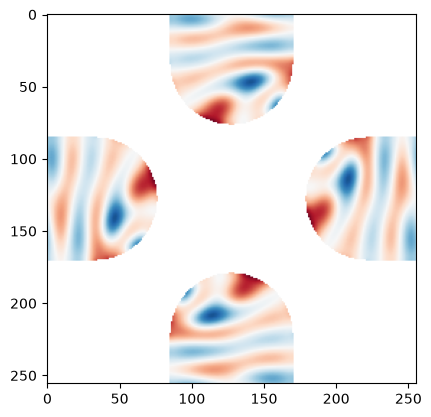

10.691090757701915


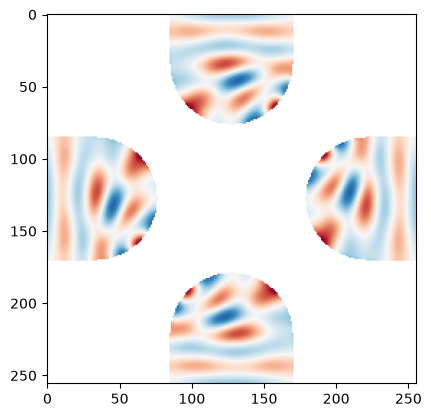

10.890924229808492


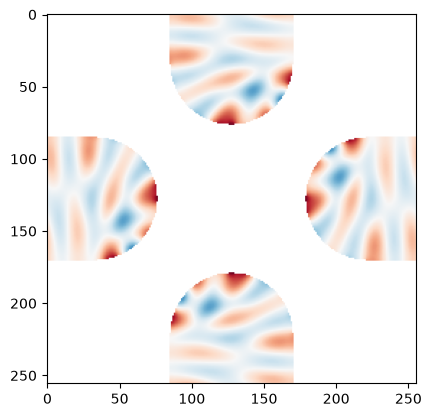

11.290591174021648


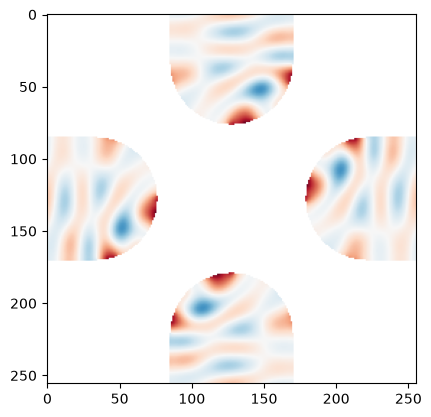

11.790174854288093


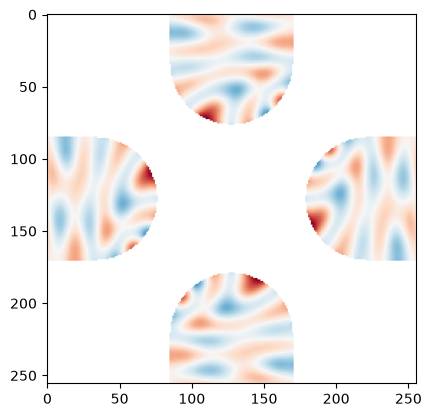

12.08992506244796


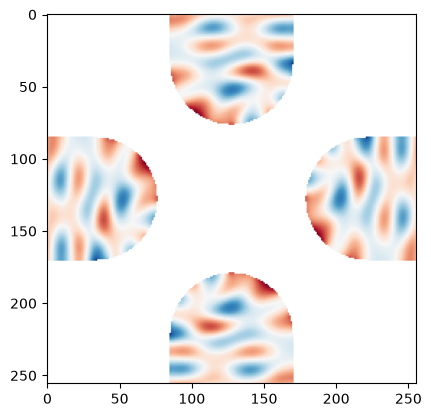

13.288925895087427


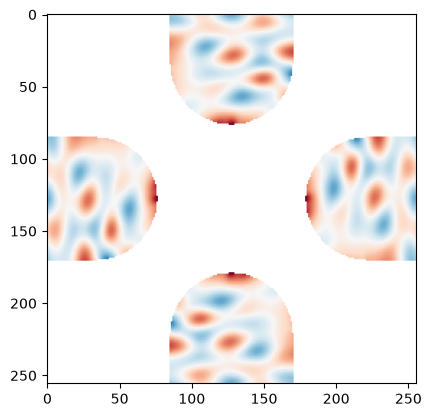

14.088259783513738


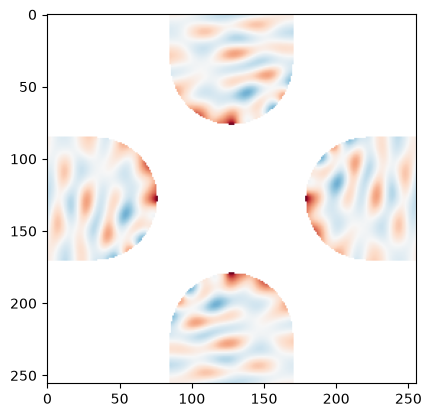

14.887593671940051


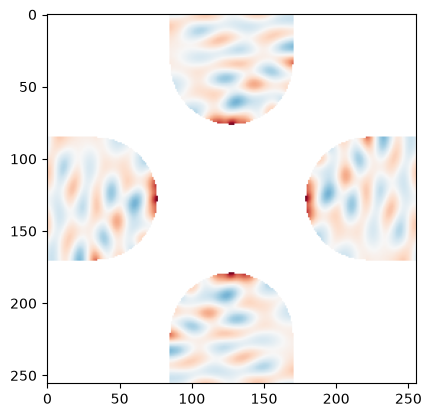

16.286427976686095


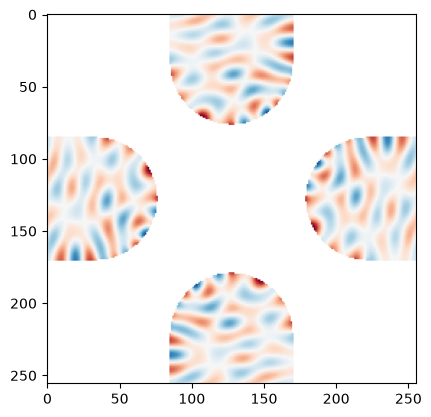

16.885928393005827


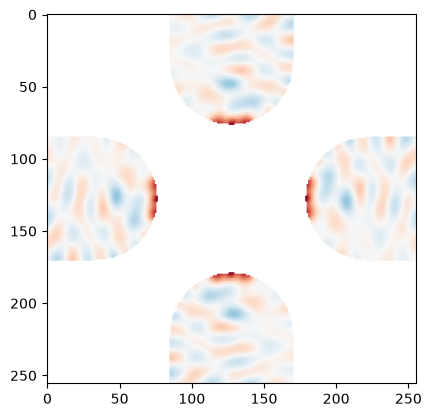

17.78517901748543


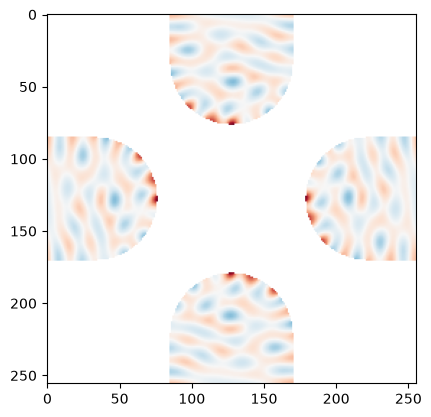

19.084096586178184


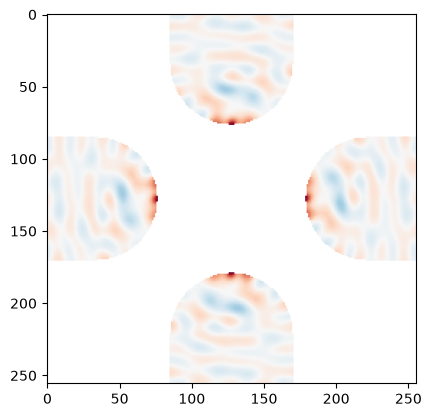

20.083263946711075


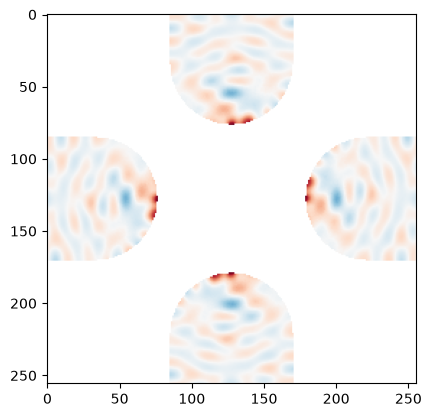

20.782681099084094


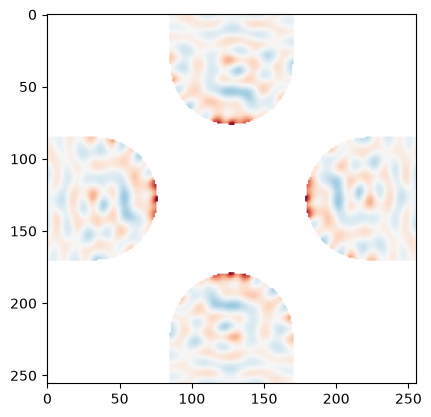

20.982514571190674


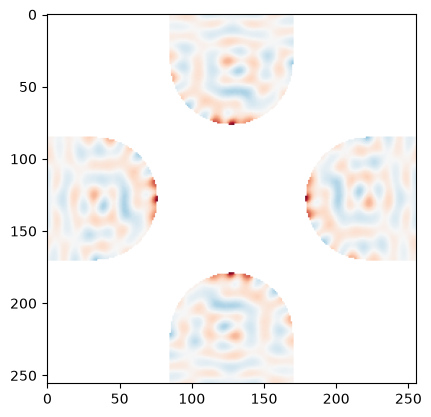

21.881765195670273


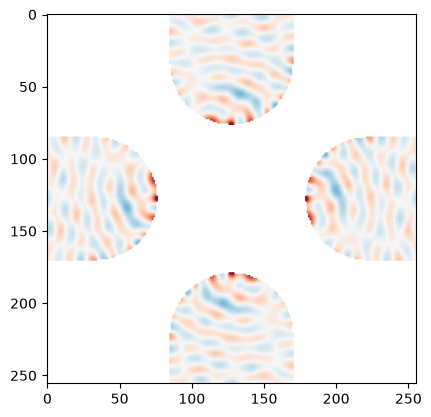

22.581182348043296


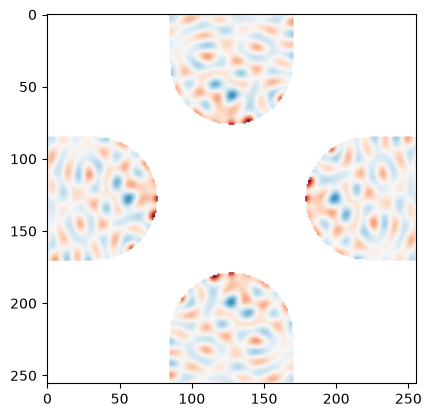

22.98084929225645


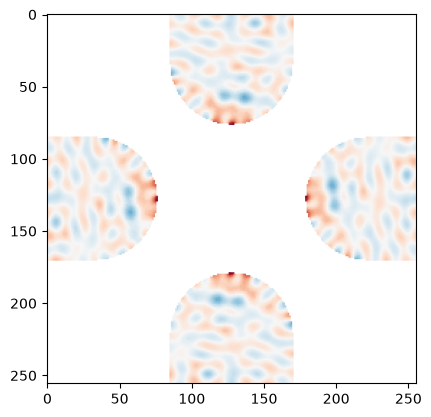

24.779350541215653


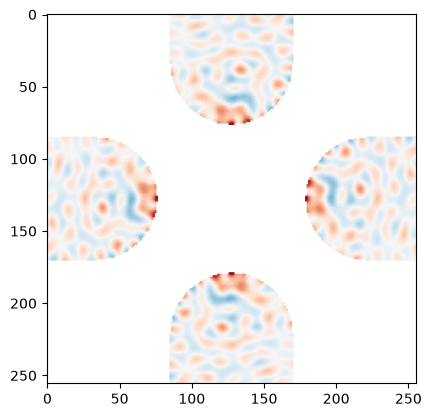

26.77768526228143


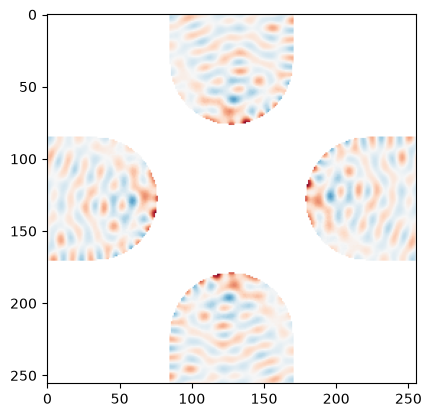

26.97751873438801


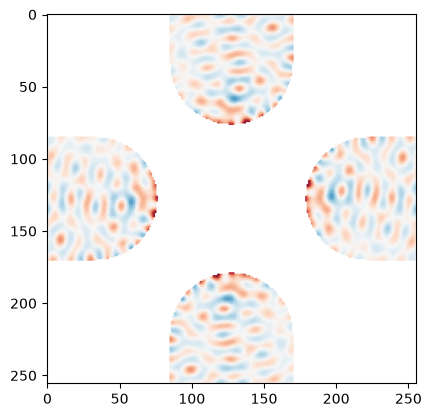

28.076602830974185


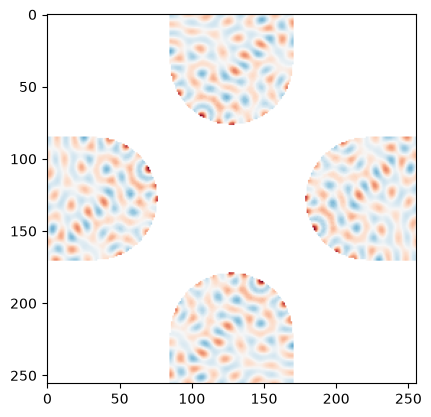

28.975853455453787


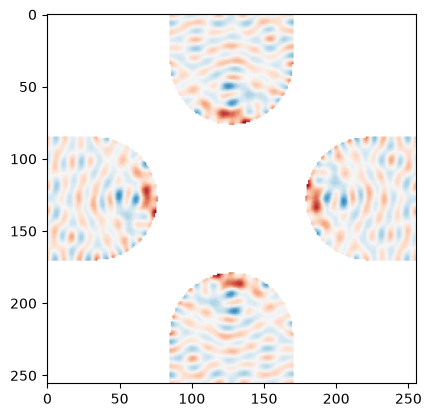

In [35]:
from scipy.signal import find_peaks
peak_idxs, _ = find_peaks(fmr[:300])
f_idx = 56
for f_idx in peak_idxs:
    print(freqs[f_idx] / 1e9)
    s = spec[f_idx].mean(axis=0)                    # average over z
    s *= np.exp(-1j*np.angle(s.flat[np.argmax(np.abs(s))]))
    v = np.abs(s.real).max()
    s[s == 0.0] = np.nan
    plt.imshow(s.real, cmap='RdBu_r', vmin=-v, vmax=v)
    # plt.imshow(np.log(s.real), cmap="RdBu_r")
    plt.show()

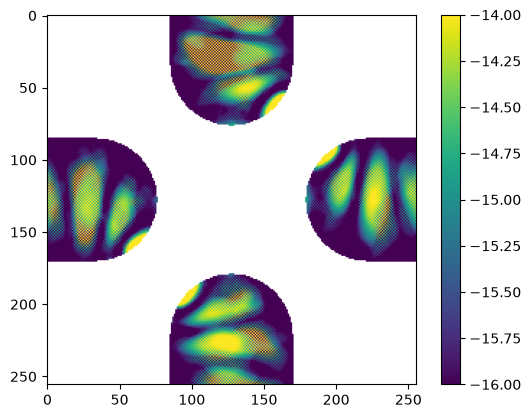

In [40]:
plt.imshow(np.log(psd[46, 4, ...]), clim=(-16, -14))
plt.colorbar()